In [1]:
import ioNERDSS as io
import matplotlib.pyplot as plt
import numpy as np
import pandas

### Load the histogram file ###


In [24]:
#Path to file
path_to_histo = "histogram_complexes_time.dat"

multi_species_01=io.MultiHistogram(FileName=path_to_histo,FileNum=1,InitialTime=0.0,FinalTime=1.0,SpeciesList=["A"])

data_01 = multi_species_01.hist_to_df(SaveCsv = False)


## Plot the timeseries

Text(0, 0.5, 'Copy Number')

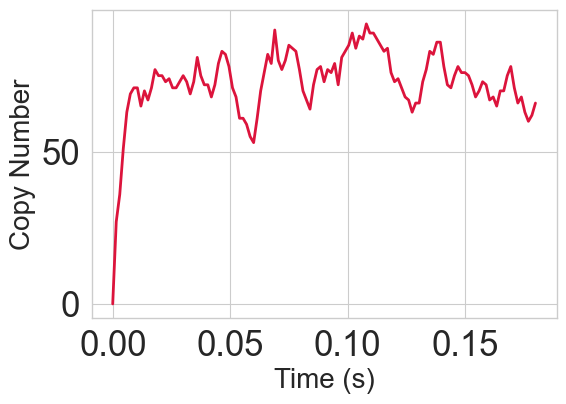

In [25]:
fig,ax = plt.subplots(figsize=(6,4))

lw=2
f_size=20
t_size=25

ax.plot(data_01['Time(s):'].to_numpy(),data_01['A: 3.  '].to_numpy(),linewidth=lw,color='crimson',label='AAA')
# ax.plot(data_01['Time(s):'].to_numpy(),data_01['A: 1.  A: 3.  A: 0.  '].to_numpy(),linewidth=lw,color='forestgreen',label='AA')
# ax.plot(data_01['Time(s):'].to_numpy(),data_01['A: 1.  A: 0.  A: 0.  '].to_numpy(),linewidth=lw,color='black',label='AAA')
ax.tick_params(labelsize=t_size)
ax.set_xlabel("Time (s)",fontsize=f_size)
ax.set_ylabel("Copy Number",fontsize=f_size)

In [26]:
print("Final Copies at time: %f sec" %(data_01['Time(s):'].to_numpy()[-1]))
print("AAA: ",data_01['A: 3.  '].to_numpy()[-1])
# print("AB: ",data_01['A: 1.  B: 1.  C: 0.  '].to_numpy()[-1])
# print("A: ",data_01['A: 1.  B: 0.  C: 0.  '].to_numpy()[-1])


Final Copies at time: 0.180000 sec
AAA:  66.0


## Calculating Time averaged copies ##


In [27]:
#Choose time point to start averaging from
time_point = 0.1

avg_data_AAA = np.mean(data_01['A: 3.  '].to_numpy()[data_01['Time(s):'].to_numpy()>time_point])
# avg_data_AB = np.mean(data_01['A: 1.  B: 1.  C: 0.  '].to_numpy()[data_01['Time(s):'].to_numpy()>time_point])
# avg_data_A = np.mean(data_01['A: 1.  B: 0.  C: 0.  '].to_numpy()[data_01['Time(s):'].to_numpy()>time_point])
print("Time Averaged AAA copies: ",avg_data_AAA)
# print("Time Averaged AB copies: ",avg_data_AB)
# print("Time Averaged A copies: ",avg_data_A)


Time Averaged AAA copies:  75.14814814814815


## Calculating Equilibrium Solution for a Heterotrimer


In [ ]:
from sympy.solvers import solve
from sympy import symbols
import numpy as np
from sympy import nsolve

ModuleNotFoundError: No module named 'sympy'

In [10]:
#Define Sympy variables
a,b,c,ab,ac,bc,abc = symbols("a,b,c,ab,ac,bc,abc")

#Define rates and other constants
k_on = np.array([1,1,1,1,1,1])      #Units - uM-1 s-1 #Order is dimer reactions the trimer reactions - [kdim,kdim,kdim,ktri,ktri,ktri]
g = np.array([-16.44,-16.44,-16.44,-32.896,-32.896,-32.896])      #Units kJ/mol #Similar order - [dG_dim,dG_dim,dG_dim,dG_tri,dG_tri,dG_tri]
R = 8.314     #Gas constant (J/mol)
T = 310       #Temp in Kelvin
C0 = 1e6      # Standard State Conc #Units- uM

#Get off rates
k_off = C0*k_on*np.exp(g*1000/(R*T))
init_conc = [100,100,100,0,0,0,0]            #Units - uM
# init_sol = np.random.rand(len(init_conc))*max(init_conc)
init_sol = [ 10,  10,  10,  2,  2,  2, 80]     #Initial Guess

#System of rate equations
eq1 = -k_on[0]*a*b - k_on[5]*a*bc -k_on[1]*a*c + k_off[0]*ab + k_off[5]*abc + k_off[1]*ac
eq2 = -k_on[0]*a*b - k_on[2]*b*c - k_on[4]*b*ac + k_off[0]*ab + k_off[4]*abc + k_off[2]*bc
eq3 = -k_on[1]*a*c -k_on[2]*b*c - k_on[3]*c*ab + k_off[1]*ac + k_off[2]*bc + k_off[3]*abc
eq4 = -k_off[0]*ab - k_on[3]*ab*c + k_on[0]*a*b + k_off[3]*abc
eq5 = -k_off[1]*ac - k_on[4]*ac*b + k_on[1]*a*c + k_off[4]*abc
eq6 = -k_off[2]*bc - k_on[5]*bc*a + k_on[2]*b*c + k_off[5]*abc
eq7 = -(k_off[3] + k_off[4] + k_off[5])*abc + k_on[3]*ab*c + k_on[4]*ac*b + k_on[5]*bc*a

#Mass conservation
c1 = a+ab+ac+abc-100.0
c2 = b+ab+bc+abc-100.0
c3 = c+ac+bc+abc-100.0

system = [eq1,eq2,eq3,eq4,eq5,eq6,eq7,c1,c2,c3]

print("Off rates: ",k_off)
print("")

solution = nsolve(system,[a,b,c,ab,ac,bc,abc],init_sol)

print("Final Equilibrium Solution: ")
print("A: ",solution[0])
print("AB: ",solution[3])
print("ABC: ",solution[-1])

Off rates:  [1697.37985112 1697.37985112 1697.37985112    2.86326804    2.86326804
    2.86326804]

Final Equilibrium Solution: 
A:  57.3383716990346
AB:  1.93691993393934
ABC:  38.7877884330867


## ODE Comparison

In [13]:
from scipy.integrate import solve_ivp
import ioNERDSS as ion

In [1]:
# in NERDSS parm.inp file, these are given for
# A(c) + A(q) <-> A(c!1).A(q!1)
onRate3Dka = 10.0   # nm^3 / us
offRatekb = 10002.80 # s^-1
sigma = 0.729108    # nm

# convert to us^-1
offRatekb /= 1e6

# translational diffusion const from A.mol
Dt = 20.0 # um^2 / s == nm^2 / us

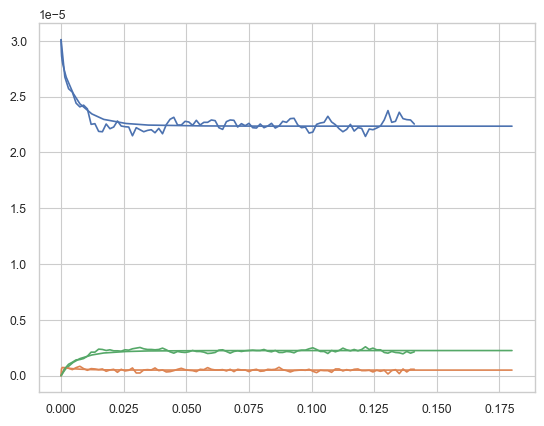

In [23]:
# for a system
#     A + A  <--> AA    k1on, k1off
#     AA + A <--> AAA   k2on, k2off
# in nerdss, there is one ka for the A+A binding, but
# the diffusion constant of AA is smaller than A, so
# the equivalent macro rate is not the same between
# the two reactions. We want ODE solutions that
# reflect this difference in kinetics. The difference
# should only be apparent when the association rate
# is high

# gives kon from ka
def equiv_macro_on(ka,sigma,D):
    return 1.0/((1.0/ka) + (1.0/(4.0*np.pi*sigma*D)) )

# gives ka from kon
def equiv_micro_on(kon,sigma,D):
    1.0/((1.0/kon) - (1.0/(4.0*np.pi*sigma*D)) )

# ODE system for above rxns
def rxn_sys(t,y,k):
    k1on,k1off,k2on,k2off,kclose,kopen = k
    A,AA,AAA,AAAc = y

    dA    = -2*k1on*A*A + 2*k1off*AA - 2*k2on*AA*A + 2*k2off*AAA
    dAA   = k1on*A*A - k1off*AA - 2*k2on*AA*A + 2*k2off*AAA
    dAAA  = 2*k2on*AA*A - 2*k2off*AAA - kclose*AAA + 3*kopen*AAAc
    dAAAc = kclose*AAA - 3*kopen*AAAc
    
    return np.array([dA,dAA,dAAA,dAAAc])


# from these microscopic NERDSS parameters,
# we get the following macro rates for
# the first reaction (A + A <--> AA)
k1on  = equiv_macro_on(onRate3Dka,sigma,2*Dt)
k1off = k1on*offRatekb/onRate3Dka

# for AA + A <--> AAA,
# D = Dt + Dt/2, since Dt for AA is Dt/2 of the monomer
k2on = equiv_macro_on(onRate3Dka,sigma,1.5*Dt)
k2off = k2on*offRatekb/onRate3Dka

 # loop coop factor of 1.0
kclose = onRate3Dka * 0.6022 * 1.0
kopen  = offRatekb

V = np.power(321.47,3.0) # nm^3
init_conc_A = 1000.0 / V # num / nm^3

tfinal = (6e5)*0.3 # us

res = solve_ivp(
    rxn_sys,
    [0.0,tfinal],
    y0=[init_conc_A,0.0,0.0,0.0],
    args=((k1on,k1off,k2on,k2off,kclose,kopen),),
    method='LSODA'
)

# time in sec on plot, so divide by 1e6
plt.plot(res.t/(1e6),res.y[0])
plt.plot(res.t/(1e6),res.y[1])
plt.plot(res.t/(1e6),res.y[2]+res.y[3])

##################
# Now, load the NERDSS data

filename = "./histogram_complexes_time.dat"

multi_species = ion.MultiHistogram(FileName=filename,FileNum=1,InitialTime=0.0,FinalTime=tfinal,SpeciesList=["A"])

data = multi_species.hist_to_df(SaveCsv = False)

times = data['Time(s):'].to_numpy()

Anums   = data['A: 1.  '].to_numpy()
AAnums  = data['A: 2.  '].to_numpy()
AAAnums = data['A: 3.  '].to_numpy()

plt.plot(times,Anums/V,color="C0")
plt.plot(times,AAnums/V,color="C1")
plt.plot(times,AAAnums/V,color="C2")

plt.show()